# Simulation of a positron-induced Muon Source

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

The threshold is: 0.044654769253196 GeV
The total cross section is: 9.27350194395824e-05 mbarn


Text(0, 0.5, 'Differential cross section [mb]')

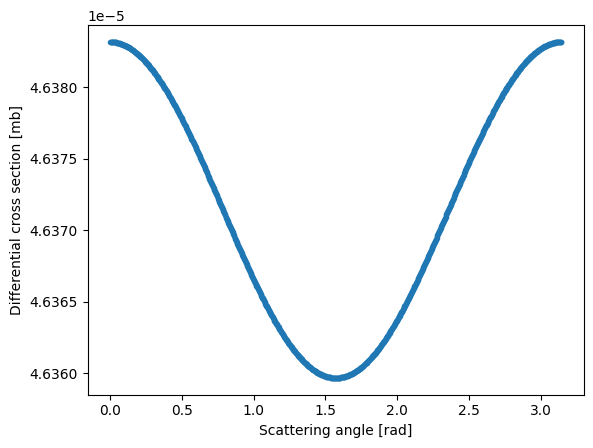

In [3]:
e = 1.602176634 * 10**(-19)     # THIS IS WRONG IN NATURAL UNITS
mass_e = 0.00051099895069
mass_mu = 0.1056583755       # we're working in GeV
alpha = 1/137
conversion_factor = 0.3894      # this is equal to (hbar * c)^2 expressed in mbarn * GeV

def cross_section(s, theta):
    ratio = 4 * mass_mu**2 / s
    return ((np.pi * alpha**2 )/ (2 * s)) * np.sqrt(1 - ratio) * (1 + ratio + (1 - ratio) * np.cos(theta)**2)

def cross_section_norm(s, cos):
    ratio = 4 * mass_mu**2 / s
    beta = np.sqrt(1 - ratio)
    return 3 / (4*(3 - beta**2)) * (1 + cos**2 + (1 - beta**2) * (1 - cos**2))


print('The threshold is:', 4*mass_mu**2, 'GeV')
s = 0.0447  # should be greater than 4 mass_mu
l = np.linspace(0, np.pi, 1000, endpoint=True)

ratio = 4 * mass_mu**2 / s
beta = np.sqrt(1 - ratio)

#total cross section integrating over solid angle
cross_section_tot = ((2 * np.pi * alpha**2) / (3 * s)) * beta * (3 - beta**2) * conversion_factor
print('The total cross section is:', cross_section_tot, 'mbarn')

fig, ax = plt.subplots()
ax.plot(l, cross_section(s, l) * conversion_factor, marker=".")
#plt.ylim(-10**-20, 10**-20)
ax.set_xlabel('Scattering angle [rad]')
ax.set_ylabel('Differential cross section [mb]')

The modulus of the outgoing momenta in the CM frame is given by: 0.14949741723569937 GeV


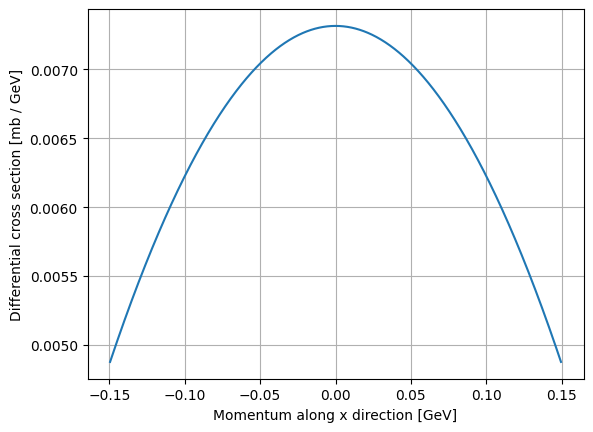

In [13]:
pmin = - beta * np.sqrt(s / 2)
pmax = beta * np.sqrt(s / 2)

print('The modulus of the outgoing momenta in the CM frame is given by:', pmax, 'GeV')

px = np.linspace(pmin, pmax, 1000)
cs_px = ((np.pi * (alpha**2)) / (s * np.sqrt(2*s))) * (2 - beta**2 / 2 - px**2 / s) * conversion_factor

fig, ax = plt.subplots()
ax.plot(px, cs_px)
ax.set_xlabel('Momentum along x direction [GeV]')
ax.set_ylabel('Differential cross section [mb / GeV]')
ax.grid()

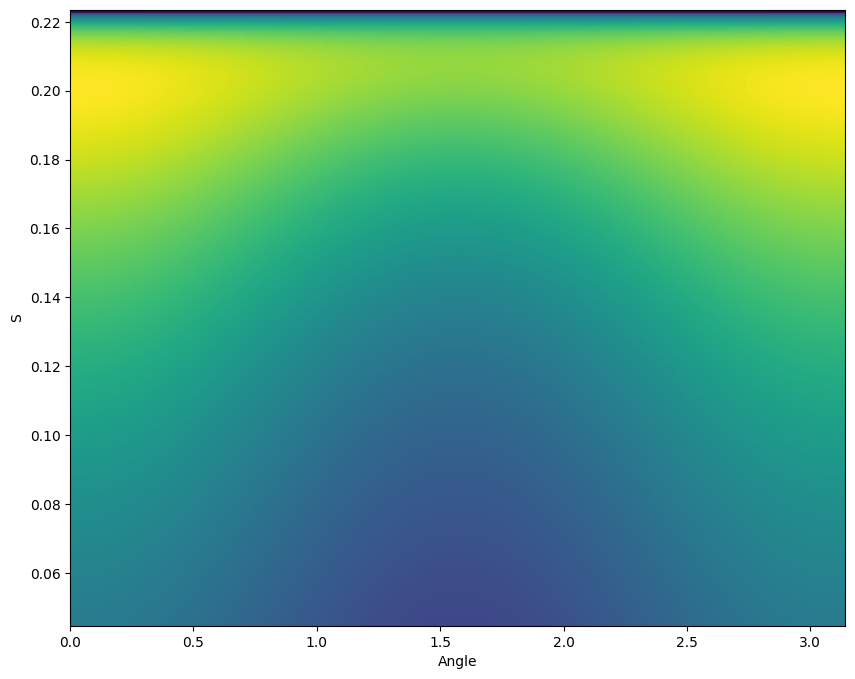

In [5]:
s_space = np.linspace(s, 5 * s, 200, endpoint=True)

xv, yv = np.meshgrid(l, s_space)

plt.figure(figsize=(10, 8))
plt.imshow(cross_section(yv, xv), extent=[0, np.pi, s, 5*s], aspect='auto')
plt.xlabel("Angle")
plt.ylabel("S")
plt.show()

<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
C:\Users\nickt\AppData\Local\Temp\ipykernel_21220\1076838534.py:20: SyntaxWarning: invalid escape sequence '\s'
  plt.title("Distribuzione angolare dei muoni (coseno) a $\sqrt{s}$ vicino alla soglia")


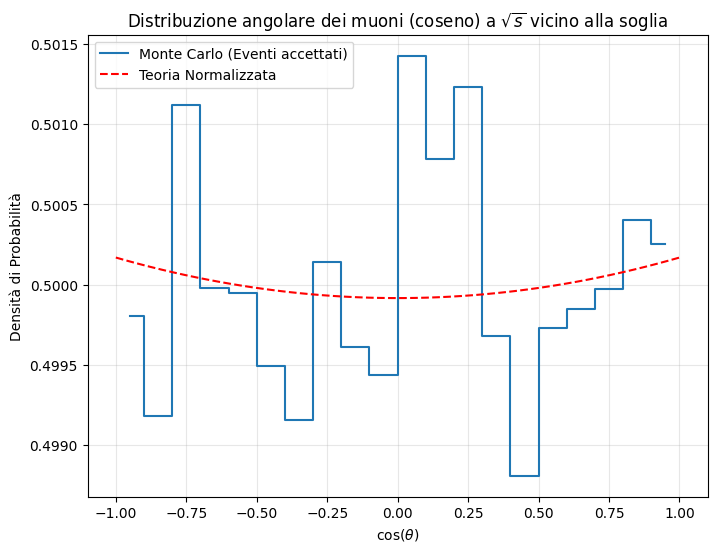

In [6]:
n = 10000000
u = np.random.uniform(-1, 1, n)
r = np.random.uniform(0, cross_section_norm(s, 1), n)
v = u[r < cross_section_norm(s, u)]

# 3. Plot di confronto
plt.figure(figsize=(8, 6))

# Istogramma del Monte Carlo (Normalizzato con density=True)
hist, bin_edges = np.histogram(v, bins=20, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.
plt.step(bin_centers, hist, where='mid', label="Monte Carlo (Eventi accettati)")

# Curva teorica normalizzata
cos_range = np.linspace(-1, 1, 50)
plt.plot(cos_range, cross_section_norm(s, cos_range), 'r--', label="Teoria Normalizzata")

plt.xlabel(r"$\cos(\theta)$")
plt.ylabel("Densità di Probabilità")
plt.title("Distribuzione angolare dei muoni (coseno) a $\sqrt{s}$ vicino alla soglia")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

NOTA SUI BOOST:

il boost non trasforma le componenti lungo gli assi x e y avendo posizionato il fascio lungo l'asse z. Tuttavia il boost lungo l'asse z modifica il modulo dei momenti e l'energia (legati dalla dispersione) come si vede dalle formule. Per la conservazione del momento questo ha senso: prima dello scattering i momenti lungo x e y erano nulli e nulli rimangono dopo lo scattering, poichè, appunto, le componenti rimangono invariate. Ma allora, cambiando i moduli, necessariamente variano gli angoli di emissione, facendo sì che l'emissione dei muoni avvenga in prossimità dell'asse z.

Concretamente: theta = sqrt(px^2 + py^2) / pz^2 --> denominatore esplode dopo la trasformazione, numeratore rimane invariato --> theta diventa piccolo

43.73734789155289


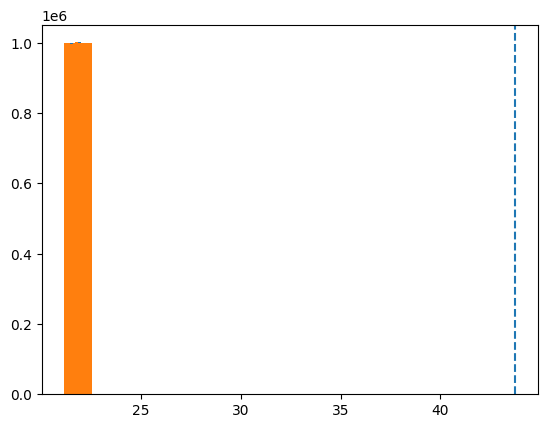

In [15]:
E_pos = (s - 2 * mass_e**2) / (2 * mass_e)      # just from s = (p_pos+p_el)**2 in the rest frame of the electron
p_pos = np.sqrt(E_pos**2 - mass_e**2)           # dispersion
gamma = (E_pos + mass_e) / np.sqrt(s)           # derive with the usual formula 1 / sqrt(1-beta**2)
beta = p_pos / (E_pos + mass_e)                 # given by p / E in the lab frame

phi = np.random.uniform(0, 2*np.pi, len(v))
p_mod = np.sqrt(s/4 - mass_mu**2)
px_cm_1 = p_mod * np.sqrt(1 - v**2) * np.cos(phi)
py_cm_1 = p_mod * np.sqrt(1 - v**2) * np.sin(phi)
pz_cm_1 = p_mod * v
E_cm_1 = np.sqrt(s)/2

px_cm_2 = -1 * p_mod * np.sqrt(1 - v**2) * np.cos(phi)
py_cm_2 = -1 * p_mod * np.sqrt(1 - v**2) * np.sin(phi)
pz_cm_2 = -1 * p_mod * v
E_cm_2 = np.sqrt(s)/2

pz_lab_1 = gamma * (pz_cm_1 + beta * E_cm_1)
E_lab_1 = gamma * (E_cm_1 + beta * pz_cm_1)

pz_lab_2 = gamma * (pz_cm_2 + beta * E_cm_2)
E_lab_2 = gamma * (E_cm_2 + beta * pz_cm_2)

#plt.hist(E_lab_1, bins=100)
#plt.hist(E_lab_2, bins=100)
#plt.hist(E_lab_2 - E_lab_1, bins=100)
#plt.scatter(E_lab_1, E_lab_2, marker=".")
#plt.title("Distribuzione Energia Muoni nel Laboratorio")
#plt.show()
plt.hist(pz_lab_1)
plt.hist(pz_lab_2)
#plt.hist(pz_lab_1 + pz_lab_2)
print(p_pos)
plt.axvline(p_pos, linestyle='--')
plt.show()


In [16]:
# point 6
d = 3                       # cm
rate = 10**6                # Hz

uma = 1.660539e-24          # unitò di massa atomica in g
B = 9.0121831               # atomic weight del berillio in uma
rho = 1.845                 # densità del berillio in g/cm^3
n = rho / (uma * B)         # densità atomica del berillio

P = n * d * cross_section_tot * 10**(-27)       # convertendo la cross section da mbarn a cm**2
T = 7 * 24 * 3600           # s

E = T * rate * P
weight = E / len(v)
print(E)
print(len(v))

print('The conversion factor is:', weight)

20744.07568659502
9996620
The conversion factor is: 0.0020751089554864564
